<a href="https://colab.research.google.com/github/hoangnguyen3101/Application-algorithms/blob/main/Lab_Thuat_toan_tham_lam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab thực hành: Thuật toán tham lam

**Môn học:** Thuật toán ứng dụng  
**Chủ đề:** Greedy Algorithms

**Mục tiêu học tập**
- Cài đặt khuôn mẫu thuật toán tham lam: sắp xếp, chọn cục bộ, cập nhật trạng thái.
- Thực hành 4 bài toán trong bài giảng: đổi tiền xu, lập lịch khoảng, ba lô phân số, mã Huffman.
- Kiểm chứng khi nào tham lam đúng và khi nào cần quy hoạch động hoặc cách tiếp cận khác.
- Phân tích độ phức tạp và giải thích tiêu chí tham lam bằng ví dụ cụ thể.
- Mở rộng sang tình huống thực tế: chọn lịch sử dụng phòng học/phòng họp không chồng lấp.

**Cách dùng notebook**
- Chạy tuần tự từ trên xuống dưới.
- Đọc yêu cầu trước khi chạy mã.
- Các ô có chữ TODO dành cho sinh viên hoàn thiện.
- Cuối notebook có bài tập nộp và câu hỏi thảo luận.


## 0. Chuẩn bị môi trường

Notebook chỉ dùng thư viện chuẩn của Python và matplotlib để vẽ minh họa. Nếu máy chưa có matplotlib, hãy cài đặt trước khi chạy phần trực quan hóa.


In [ ]:
# Nếu chạy trên Google Colab hoặc môi trường chưa có matplotlib, bỏ dấu # ở dòng dưới.
!pip -q install matplotlib


In [4]:
from dataclasses import dataclass
import heapq
import math
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"


## 1. Khuôn mẫu tư duy tham lam

Một thuật toán tham lam thường có dạng:

1. **Mô hình hóa** bài toán tối ưu.
2. **Chọn tiêu chí tham lam**: mỗi bước chọn gì là tốt nhất ngay lúc này?
3. **Sắp xếp hoặc dùng hàng đợi ưu tiên** để luôn lấy được lựa chọn tốt nhất.
4. **Cập nhật trạng thái** và không xét lại lựa chọn đã chọn.
5. **Chứng minh hoặc phản chứng**: tiêu chí này có luôn dẫn đến tối ưu toàn cục không?

Trong bài thực hành, mỗi bài toán đều có phần cài đặt, chạy ví dụ trong lý thuyết, kiểm thử nhanh và câu hỏi phân tích.


In [8]:
def show_result(title, value):
    print("=" * 70)
    print(title)
    print("=" * 70)
    print(value)


## 2. Bài toán đổi tiền xu

**Bài toán:** Cho tập mệnh giá D và số tiền n. Tìm số đồng xu ít nhất có tổng bằng n.

**Tiêu chí tham lam:** luôn chọn mệnh giá lớn nhất không vượt quá số tiền còn lại.

Lưu ý quan trọng trong bài giảng: tham lam đổi tiền **không luôn đúng** với mọi hệ mệnh giá. Vì vậy ta sẽ so sánh với quy hoạch động.


In [6]:
def greedy_change(amount, denominations):
    """Trả về danh sách đồng xu theo chiến lược tham lam."""
    coins = []
    remaining = amount
    for coin in sorted(denominations, reverse=True):
        count = remaining // coin
        coins.extend([coin] * count)
        remaining -= coin * count

    if remaining != 0:
        raise ValueError("Không thể đổi đúng số tiền với tập mệnh giá đã cho")

    return coins

coins = greedy_change(41, [25, 10, 5, 1])
show_result("Đổi 41 xu với mệnh giá [25, 10, 5, 1]", coins)
print("Số đồng xu:", len(coins))


Đổi 41 xu với mệnh giá [25, 10, 5, 1]
[25, 10, 5, 1]
Số đồng xu: 4


### 2.1. Quy hoạch động để kiểm tra nghiệm tối ưu

Ta dùng DP làm máy kiểm chứng cho bài toán đổi tiền tổng quát:

dp[x] = 1 + min(dp[x - d]) với mọi mệnh giá d không vượt quá x.

Nếu số đồng xu của tham lam lớn hơn số đồng xu của DP, ta đã tìm được phản ví dụ.


In [10]:
def optimal_change_dp(amount, denominations):
    """Trả về một nghiệm tối ưu có ít đồng xu nhất bằng quy hoạch động."""
    dp = [math.inf] * (amount + 1)
    prev = [None] * (amount + 1)
    dp[0] = 0

    for x in range(1, amount + 1):
        for coin in denominations:
            if coin <= x and dp[x - coin] + 1 < dp[x]:
                dp[x] = dp[x - coin] + 1
                prev[x] = coin

    if dp[amount] == math.inf:
        return None

    result = []
    x = amount
    while x > 0:
        coin = prev[x]
        result.append(coin)
        x -= coin

    return result

D = [4, 3, 1]
amount = 6

greedy = greedy_change(amount, D)
optimal = optimal_change_dp(amount, D)

print("Mệnh giá:", D)
print("Số tiền:", amount)
print("Tham lam:", greedy, "- số xu:", len(greedy))
print("Tối ưu DP:", optimal, "- số xu:", len(optimal))


Mệnh giá: [4, 3, 1]
Số tiền: 6
Tham lam: [4, 1, 1] - số xu: 3
Tối ưu DP: [3, 3] - số xu: 2


### 2.2. Bài tập nhanh

Hãy sửa ô dưới để kiểm tra các hệ mệnh giá sau:

- [7, 3, 1], đổi 11 xu.
- [10, 6, 1], đổi 12 xu.
- [5000, 2000, 1000, 500], đổi 13500 đồng.

Với mỗi trường hợp, trả lời: tham lam có tối ưu không?


In [13]:
# TODO: thay đổi denominations và amount, sau đó so sánh greedy với DP.
denominations = [5000, 2000, 1000, 500]
amount = 13500

greedy = greedy_change(amount, denominations)
optimal = optimal_change_dp(amount, denominations)

print("Tham lam:", greedy, len(greedy))
print("Tối ưu:", optimal, len(optimal))
print("Tham lam tối ưu?", len(greedy) == len(optimal))


Tham lam: [5000, 5000, 2000, 1000, 500] 5
Tối ưu: [5000, 5000, 2000, 1000, 500] 5
Tham lam tối ưu? True


## 3. Bài toán lập lịch khoảng

**Bài toán:** Chọn nhiều hoạt động nhất sao cho không có hai hoạt động chồng lấp.

Mỗi hoạt động có dạng: (id, start, finish).

**Tiêu chí tham lam đúng:** chọn hoạt động có thời điểm kết thúc sớm nhất trong số các hoạt động còn tương thích.


In [16]:
@dataclass(frozen=True)
class Activity:
    id: str
    start: int
    finish: int


def greedy_activity_selection(activities):
    selected = []
    current_finish = -math.inf

    for act in sorted(activities, key=lambda x: (x.finish, x.start)):
        if act.start >= current_finish:
            selected.append(act)
            current_finish = act.finish

    return selected

activities = [
    Activity("a1", 1, 4), Activity("a2", 3, 5), Activity("a3", 0, 6),
    Activity("a4", 5, 7), Activity("a5", 3, 9), Activity("a6", 5, 9),
    Activity("a7", 6, 10), Activity("a8", 8, 11), Activity("a9", 8, 12),
    Activity("a10", 2, 14), Activity("a11", 12, 16),
]

selected = greedy_activity_selection(activities)
print("Các hoạt động được chọn:")
for act in selected:
    print(act)

assert [a.id for a in selected] == ["a1", "a4", "a8", "a11"]


Các hoạt động được chọn:
Activity(id='a1', start=1, finish=4)
Activity(id='a4', start=5, finish=7)
Activity(id='a8', start=8, finish=11)
Activity(id='a11', start=12, finish=16)


### 3.1. Trực quan hóa lịch hoạt động

Màu xanh là hoạt động được chọn, màu xám là hoạt động bị bỏ.


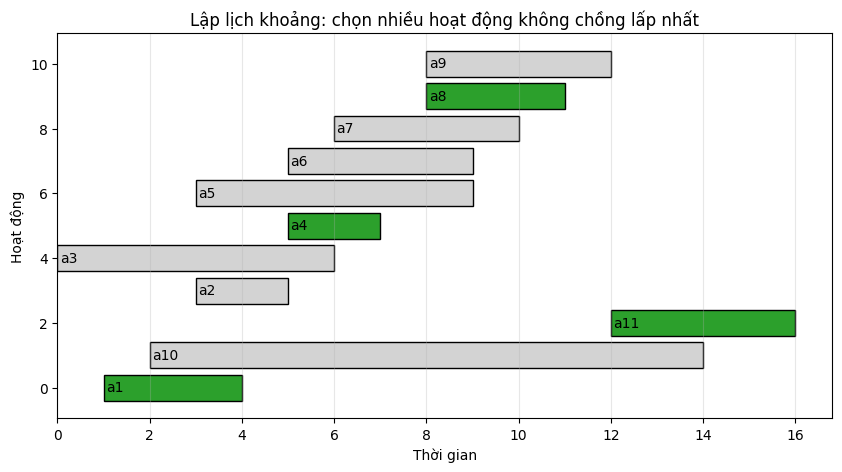

In [15]:
def plot_activities(activities, selected):
    selected_ids = {a.id for a in selected}

    plt.figure(figsize=(10, 5))
    for i, act in enumerate(sorted(activities, key=lambda x: x.id)):
        color = "tab:green" if act.id in selected_ids else "lightgray"
        plt.barh(i, act.finish - act.start, left=act.start, color=color, edgecolor="black")
        plt.text(act.start + 0.05, i, act.id, va="center", ha="left")

    plt.xlabel("Thời gian")
    plt.ylabel("Hoạt động")
    plt.title("Lập lịch khoảng: chọn nhiều hoạt động không chồng lấp nhất")
    plt.grid(axis="x", alpha=0.3)
    plt.show()

plot_activities(activities, selected)


### 3.2. So sánh với vài tiêu chí sai

Không phải tiêu chí nào nghe hợp lý cũng đúng. Ta thử:

- chọn hoạt động bắt đầu sớm nhất,
- chọn hoạt động ngắn nhất,
- chọn hoạt động kết thúc sớm nhất.

Hãy quan sát số hoạt động chọn được.


In [17]:
def greedy_by_rule(activities, key_func):
    selected = []
    current_finish = -math.inf

    for act in sorted(activities, key=key_func):
        if act.start >= current_finish:
            selected.append(act)
            current_finish = act.finish

    return selected

rules = {
    "Bắt đầu sớm nhất": lambda a: (a.start, a.finish),
    "Khoảng ngắn nhất": lambda a: (a.finish - a.start, a.finish),
    "Kết thúc sớm nhất": lambda a: (a.finish, a.start),
}

for name, key in rules.items():
    result = greedy_by_rule(activities, key)
    print(name, "=>", [a.id for a in result], "số lượng:", len(result))


Bắt đầu sớm nhất => ['a3', 'a7', 'a11'] số lượng: 3
Khoảng ngắn nhất => ['a2', 'a4', 'a8', 'a11'] số lượng: 4
Kết thúc sớm nhất => ['a1', 'a4', 'a8', 'a11'] số lượng: 4


## 4. Bài toán ba lô phân số

**Bài toán:** Có thể lấy một phần của đồ vật. Tối đa hóa tổng giá trị với sức chứa W.

**Tiêu chí tham lam đúng:** sắp xếp theo mật độ giá trị v/w giảm dần, lấy đầy theo thứ tự đó.


In [18]:
@dataclass(frozen=True)
class Item:
    name: str
    weight: float
    value: float

    @property
    def ratio(self):
        return self.value / self.weight


def fractional_knapsack(items, capacity):
    total_value = 0
    plan = []
    remaining = capacity

    for item in sorted(items, key=lambda x: x.ratio, reverse=True):
        if remaining <= 0:
            break

        take_weight = min(item.weight, remaining)
        fraction = take_weight / item.weight
        gained_value = fraction * item.value

        plan.append({"item": item.name, "fraction": fraction, "weight": take_weight, "value": gained_value, "ratio": item.ratio})
        total_value += gained_value
        remaining -= take_weight

    return total_value, plan

items = [Item("1", 10, 60), Item("2", 20, 100), Item("3", 30, 120)]
value, plan = fractional_knapsack(items, capacity=50)
print("Tổng giá trị:", value)
for row in plan:
    print(row)


Tổng giá trị: 240.0
{'item': '1', 'fraction': 1.0, 'weight': 10, 'value': 60.0, 'ratio': 6.0}
{'item': '2', 'fraction': 1.0, 'weight': 20, 'value': 100.0, 'ratio': 5.0}
{'item': '3', 'fraction': 0.6666666666666666, 'weight': 20, 'value': 80.0, 'ratio': 4.0}


### 4.1. Vì sao ba lô 0-1 không dùng cùng chiến lược?

Với ba lô 0-1, đồ vật phải lấy nguyên hoặc bỏ. Tiêu chí v/w có thể thất bại.

Ví dụ trong bài giảng:
- capacity = 50,
- các đồ vật: (w, v) = (10, 60), (20, 100), (30, 120).

Tham lam theo v/w lấy đồ 1 và 2, tổng 160. Nhưng nghiệm 0-1 tốt hơn là đồ 2 và 3, tổng 220.


In [19]:
def zero_one_knapsack_bruteforce(items, capacity):
    """Bruteforce để kiểm chứng trên bộ dữ liệu nhỏ."""
    n = len(items)
    best_value = -1
    best_subset = []

    for mask in range(1 << n):
        total_weight = 0
        total_value = 0
        subset = []

        for i in range(n):
            if mask & (1 << i):
                total_weight += items[i].weight
                total_value += items[i].value
                subset.append(items[i])

        if total_weight <= capacity and total_value > best_value:
            best_value = total_value
            best_subset = subset

    return best_value, best_subset

best_value, best_subset = zero_one_knapsack_bruteforce(items, 50)
print("Tối ưu 0-1:", best_value, [x.name for x in best_subset])


Tối ưu 0-1: 220 ['2', '3']


## 5. Mã Huffman

**Bài toán:** Cho tần suất xuất hiện của các ký tự. Xây dựng mã nhị phân không tiền tố sao cho tổng số bit là nhỏ nhất.

**Tiêu chí tham lam đúng:** mỗi bước hợp nhất hai nút có tần suất thấp nhất.

Ta dùng heapq để cài đặt min-heap.


In [20]:
@dataclass(order=True)
class HuffmanNode:
    freq: int
    order: int
    symbol: str = None
    left: object = None
    right: object = None


def build_huffman_tree(frequencies):
    heap = []
    order = 0
    for symbol, freq in frequencies.items():
        heapq.heappush(heap, HuffmanNode(freq=freq, order=order, symbol=symbol))
        order += 1
    if len(heap) == 1:
        only = heapq.heappop(heap)
        return HuffmanNode(freq=only.freq, order=order, left=only)
    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        parent = HuffmanNode(freq=left.freq + right.freq, order=order, left=left, right=right)
        order += 1
        heapq.heappush(heap, parent)
    return heap[0]


def build_codes(node, prefix="", codes=None):
    if codes is None:
        codes = {}
    if node.symbol is not None:
        codes[node.symbol] = prefix or "0"
        return codes
    if node.left is not None:
        build_codes(node.left, prefix + "0", codes)
    if node.right is not None:
        build_codes(node.right, prefix + "1", codes)
    return codes


def encoded_length(frequencies, codes):
    return sum(frequencies[symbol] * len(code) for symbol, code in codes.items())

frequencies = {"a": 45_000, "b": 13_000, "c": 12_000, "d": 16_000, "e": 9_000, "f": 5_000}
root = build_huffman_tree(frequencies)
codes = build_codes(root)
print("Mã Huffman:")
for symbol in sorted(codes):
    print(symbol, "=>", codes[symbol])
huffman_bits = encoded_length(frequencies, codes)
fixed_bits = sum(frequencies.values()) * math.ceil(math.log2(len(frequencies)))
print("\nSố bit Huffman:", huffman_bits)
print("Số bit mã cố định:", fixed_bits)
print("Tiết kiệm:", round((1 - huffman_bits / fixed_bits) * 100, 2), "%")


Mã Huffman:
a => 0
b => 101
c => 100
d => 111
e => 1101
f => 1100

Số bit Huffman: 224000
Số bit mã cố định: 300000
Tiết kiệm: 25.33 %


### 5.1. Mã hóa và giải mã một chuỗi

Phần này giúp thấy Huffman không chỉ là cây lý thuyết mà còn dùng được để nén dữ liệu ký tự.


In [ ]:
def huffman_encode(text, codes):
    return "".join(codes[ch] for ch in text)


def huffman_decode(bits, root):
    result = []
    node = root
    for bit in bits:
        node = node.left if bit == "0" else node.right
        if node.symbol is not None:
            result.append(node.symbol)
            node = root
    return "".join(result)

sample = "face"
encoded = huffman_encode(sample, codes)
decoded = huffman_decode(encoded, root)
print("Chuỗi gốc:", sample)
print("Mã hóa:", encoded)
print("Giải mã:", decoded)
assert decoded == sample


## 6. Bài mở rộng thực tế: tối ưu lịch phòng học/phòng họp

**Tình huống:** Một phòng học chỉ phục vụ được một lớp tại một thời điểm. Có nhiều yêu cầu đặt phòng, mỗi yêu cầu có giờ bắt đầu và giờ kết thúc. Ta muốn chọn được **nhiều yêu cầu nhất** mà không chồng lấp.

Đây chính là bài toán lập lịch khoảng trong thực tế.

Mục tiêu thực hành:
- chuyển dữ liệu thực tế thành Activity,
- chạy tham lam theo thời điểm kết thúc sớm nhất,
- in lịch phòng được chấp nhận,
- giải thích yêu cầu nào bị từ chối và vì sao.


Lịch được chấp nhận:
R01: 7:00-9:00 | CTDL-01
R03: 9:00-11:00 | TTUD-01
R05: 11:00-13:00 | CSDL-01
R06: 13:00-15:00 | TTUD-02
R08: 15:00-17:00 | CTDL-02

Yêu cầu bị từ chối:
R02: 8:00-10:00 | AI-01
R04: 10:00-12:00 | MMT-01
R07: 14:00-16:00 | AI-02


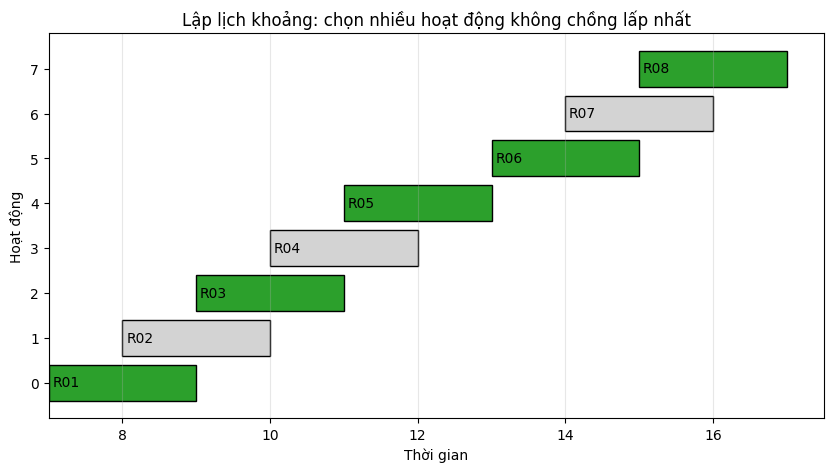

In [21]:
room_requests = [
    {"id": "R01", "start": 7, "finish": 9, "group": "CTDL-01"},
    {"id": "R02", "start": 8, "finish": 10, "group": "AI-01"},
    {"id": "R03", "start": 9, "finish": 11, "group": "TTUD-01"},
    {"id": "R04", "start": 10, "finish": 12, "group": "MMT-01"},
    {"id": "R05", "start": 11, "finish": 13, "group": "CSDL-01"},
    {"id": "R06", "start": 13, "finish": 15, "group": "TTUD-02"},
    {"id": "R07", "start": 14, "finish": 16, "group": "AI-02"},
    {"id": "R08", "start": 15, "finish": 17, "group": "CTDL-02"},
]
real_activities = [Activity(r["id"], r["start"], r["finish"]) for r in room_requests]
accepted = greedy_activity_selection(real_activities)
accepted_ids = {a.id for a in accepted}
print("Lịch được chấp nhận:")
for act in accepted:
    group = next(r["group"] for r in room_requests if r["id"] == act.id)
    print(f"{act.id}: {act.start}:00-{act.finish}:00 | {group}")
print("\nYêu cầu bị từ chối:")
for r in room_requests:
    if r["id"] not in accepted_ids:
        print(f"{r['id']}: {r['start']}:00-{r['finish']}:00 | {r['group']}")
plot_activities(real_activities, accepted)


### 6.1. Khi thực tế có trọng số

Nếu mỗi yêu cầu có số sinh viên khác nhau, mục tiêu có thể đổi thành:

**Chọn lịch sao cho tổng số sinh viên được phục vụ là lớn nhất.**

Khi đó bài toán trở thành weighted activity selection. Tiêu chí "kết thúc sớm nhất" có thể không còn tối ưu.

Ví dụ dưới đây minh họa phản ví dụ nhỏ.


In [22]:
weighted_requests = [
    {"id": "A", "start": 8, "finish": 9, "students": 10},
    {"id": "B", "start": 9, "finish": 10, "students": 10},
    {"id": "C", "start": 8, "finish": 10, "students": 25},
]
weighted_activities = [Activity(r["id"], r["start"], r["finish"]) for r in weighted_requests]
greedy_weighted = greedy_activity_selection(weighted_activities)
print("Tham lam theo kết thúc sớm nhất chọn:", [a.id for a in greedy_weighted])
print("Tổng sinh viên:", sum(r["students"] for r in weighted_requests if r["id"] in {a.id for a in greedy_weighted}))
print("Nghiệm tốt hơn: chọn ['C'] với 25 sinh viên")


Tham lam theo kết thúc sớm nhất chọn: ['A', 'B']
Tổng sinh viên: 20
Nghiệm tốt hơn: chọn ['C'] với 25 sinh viên


## 7. Bài tập cho sinh viên

### Bài tập 1: Đổi tiền xu

Viết hàm find_counterexample(denominations, max_amount) để tìm số tiền nhỏ nhất mà tham lam không tối ưu.

Gợi ý:
- duyệt amount từ 1 đến max_amount,
- so sánh số xu của greedy_change và optimal_change_dp,
- trả về phản ví dụ đầu tiên.


In [23]:
def find_counterexample(denominations, max_amount):
    for amount in range(1, max_amount + 1):
        try:
            greedy = greedy_change(amount, denominations)
        except ValueError:
            continue

        optimal = optimal_change_dp(amount, denominations)

        if optimal is not None and len(greedy) > len(optimal):
            return {
                "amount": amount,
                "greedy": greedy,
                "greedy_count": len(greedy),
                "optimal": optimal,
                "optimal_count": len(optimal)
            }

    return None


print(find_counterexample([4, 3, 1], 30))

{'amount': 6, 'greedy': [4, 1, 1], 'greedy_count': 3, 'optimal': [3, 3], 'optimal_count': 2}


### Bài tập 2: Lập lịch khoảng

Cho thêm hoạt động a12 = (2, 5) vào bộ dữ liệu CLRS trong bài giảng. Chạy lại thuật toán và cho biết tập hoạt động được chọn.


In [24]:
# TODO: thêm Activity("a12", 2, 5), chạy greedy_activity_selection và in kết quả.
activities_with_a12 = activities + [Activity("a12", 2, 5)]

selected = greedy_activity_selection(activities_with_a12)

print("Các hoạt động được chọn:")
for act in selected:
    print(act)

print("ID được chọn:", [a.id for a in selected])

Các hoạt động được chọn:
Activity(id='a1', start=1, finish=4)
Activity(id='a4', start=5, finish=7)
Activity(id='a8', start=8, finish=11)
Activity(id='a11', start=12, finish=16)
ID được chọn: ['a1', 'a4', 'a8', 'a11']


### Bài tập 3: Ba lô phân số

Một xe cứu trợ có tải trọng 100 kg. Các mặt hàng có trọng lượng và mức độ ưu tiên như sau:

| Hàng | Trọng lượng | Giá trị |
|---|---:|---:|
| Thuốc | 20 | 100 |
| Nước | 50 | 150 |
| Lương khô | 30 | 120 |
| Chăn | 40 | 80 |

Hãy dùng fractional_knapsack để lập phương án lấy hàng tối ưu.


In [25]:
# TODO: tạo danh sách Item và chạy fractional_knapsack.
relief_items = [
    Item("Thuốc", 20, 100),
    Item("Nước", 50, 150),
    Item("Lương khô", 30, 120),
    Item("Chăn", 40, 80),
]

value, plan = fractional_knapsack(relief_items, capacity=100)

print("Tổng giá trị:", value)
print("Phương án lấy hàng:")
for row in plan:
    print(row)

Tổng giá trị: 370.0
Phương án lấy hàng:
{'item': 'Thuốc', 'fraction': 1.0, 'weight': 20, 'value': 100.0, 'ratio': 5.0}
{'item': 'Lương khô', 'fraction': 1.0, 'weight': 30, 'value': 120.0, 'ratio': 4.0}
{'item': 'Nước', 'fraction': 1.0, 'weight': 50, 'value': 150.0, 'ratio': 3.0}


### Bài tập 4: Huffman

Xây dựng mã Huffman cho tần suất: {"a": 10, "b": 5, "c": 3, "d": 2}.

Sau đó tính tổng số bit nếu tệp có đúng các tần suất trên.


In [26]:
# TODO: dùng build_huffman_tree, build_codes, encoded_length.
frequencies2 = {"a": 10, "b": 5, "c": 3, "d": 2}

root2 = build_huffman_tree(frequencies2)
codes2 = build_codes(root2)

print("Mã Huffman:")
for symbol in sorted(codes2):
    print(symbol, "=>", codes2[symbol])

total_bits = encoded_length(frequencies2, codes2)

print("Tổng số bit:", total_bits)

Mã Huffman:
a => 0
b => 10
c => 111
d => 110
Tổng số bit: 35


### Bài tập 5: Mở rộng thực tế

Tự tạo ít nhất 10 yêu cầu đặt phòng trong một ngày. Mỗi yêu cầu gồm:
- mã yêu cầu,
- giờ bắt đầu,
- giờ kết thúc,
- tên lớp hoặc nhóm.

Yêu cầu:
1. Chạy thuật toán chọn nhiều yêu cầu nhất.
2. Vẽ lịch bằng plot_activities.
3. Viết nhận xét: nếu mục tiêu đổi thành tối đa số sinh viên, thuật toán hiện tại có còn phù hợp không?


Lịch được chấp nhận:
R01: 7:00-8:00 | AI-01
R03: 8:00-10:00 | ML-01
R05: 10:00-12:00 | Python-01
R07: 12:00-14:00 | DB-01
R09: 14:00-16:00 | CV-01

Yêu cầu bị từ chối:
R02: 7:00-9:00 | Data-01
R04: 9:00-11:00 | Java-01
R06: 11:00-13:00 | Web-01
R08: 13:00-15:00 | Security-01
R10: 15:00-17:00 | NLP-01


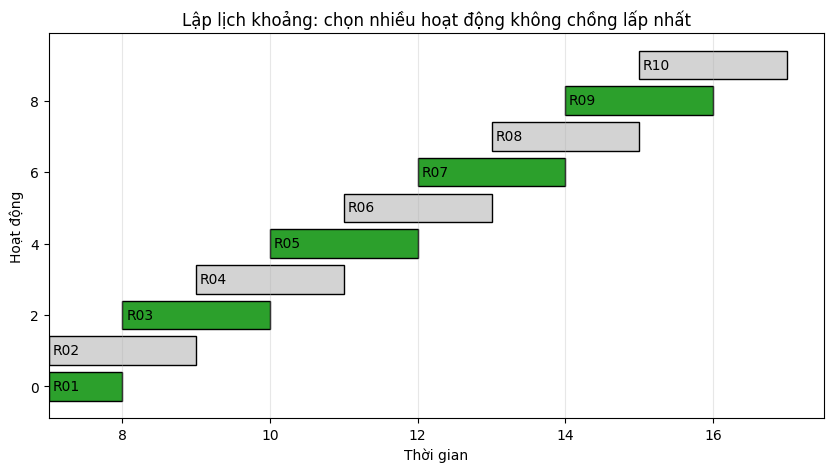

In [27]:
# TODO: tạo dữ liệu room_requests mới và chạy lại toàn bộ quy trình ở phần 6.
my_room_requests = [
    {"id": "R01", "start": 7, "finish": 8, "group": "AI-01"},
    {"id": "R02", "start": 7, "finish": 9, "group": "Data-01"},
    {"id": "R03", "start": 8, "finish": 10, "group": "ML-01"},
    {"id": "R04", "start": 9, "finish": 11, "group": "Java-01"},
    {"id": "R05", "start": 10, "finish": 12, "group": "Python-01"},
    {"id": "R06", "start": 11, "finish": 13, "group": "Web-01"},
    {"id": "R07", "start": 12, "finish": 14, "group": "DB-01"},
    {"id": "R08", "start": 13, "finish": 15, "group": "Security-01"},
    {"id": "R09", "start": 14, "finish": 16, "group": "CV-01"},
    {"id": "R10", "start": 15, "finish": 17, "group": "NLP-01"},
]

my_activities = [
    Activity(r["id"], r["start"], r["finish"])
    for r in my_room_requests
]

accepted = greedy_activity_selection(my_activities)
accepted_ids = {a.id for a in accepted}

print("Lịch được chấp nhận:")
for act in accepted:
    group = next(r["group"] for r in my_room_requests if r["id"] == act.id)
    print(f"{act.id}: {act.start}:00-{act.finish}:00 | {group}")

print("\nYêu cầu bị từ chối:")
for r in my_room_requests:
    if r["id"] not in accepted_ids:
        print(f"{r['id']}: {r['start']}:00-{r['finish']}:00 | {r['group']}")

plot_activities(my_activities, accepted)

**Nhận xét** Bài toán đặt phòng được mô hình hóa thành bài toán lựa chọn hoạt động. Mỗi yêu cầu đặt phòng là một hoạt động có thời gian bắt đầu và thời gian kết thúc. Mục tiêu là chọn được nhiều yêu cầu nhất sao cho không có hai yêu cầu nào bị chồng lấp thời gian.

Thuật toán tham lam được áp dụng bằng cách sắp xếp các yêu cầu theo thời gian kết thúc tăng dần, sau đó lần lượt chọn yêu cầu đầu tiên không xung đột với yêu cầu đã chọn trước đó. Cách chọn này hợp lý vì hoạt động kết thúc càng sớm thì càng để lại nhiều thời gian trống cho các hoạt động tiếp theo.

Với bộ dữ liệu thử nghiệm gồm 10 yêu cầu đặt phòng, thuật toán chọn được các yêu cầu không giao nhau về thời gian, ví dụ R01, R03, R05, R07 và R09. Các yêu cầu còn lại bị từ chối do bị trùng thời gian với lịch đã được chấp nhận.